# Implementing AdalineSGD algorithm in Python3

The implementation is inspired by the "*Machine Learning with PyTorch and Scikit-Learn*" book from S. Raschka. Original implementation may be found [here](https://github.com/rasbt/machine-learning-book/blob/main/ch02/ch02.ipynb).

Imagine that we have a very large dataset with millions of data points, which is not uncommon in many machine learning applications. Running full batch gradient descent can be computationally quite costly in such scenarios, since we need to reevaluate the whole training dataset each time we take one step toward the global minimum.

A popular alternative to the batch gradient descent algorithm is stochastic gradient descent (SGD), which is sometimes also called iterative or online gradient descent.

Although SGD can be considered as an approximation of gradient descent, it typically reaches con- vergence much faster because of the more frequent weight updates. Since each gradient is calculated based on a single training example, the error surface is noisier than in gradient descent, which can also have the advantage that SGD can escape shallow local minima more readily if we are working with nonlinear loss functions. To obtain satisfying results via SGD, it is important to present training data in a random order; also, we want to shuffle the training dataset for every epoch to prevent cycles.

Since we already implemented the Adaline learning rule using gradient descent, we only need to make a few adjustments to modify the learning algorithm to update the weights via SGD. Inside the ```fit``` method, we will now update the weights after each training example. Furthermore, we will implement an additional ```partial_fit``` method, which does not reinitialize the weights, for online learning.

In order to check whether our algorithm converged after training, we will calculate the loss as the average loss of the training examples in each epoch. Furthermore, we will add an option to shuffle the training data before each epoch to avoid repetitive cycles when we are optimizing the loss function; via the ```random_state``` parameter, we allow the specification of a random seed for reproducibility.

In [1]:
import numpy as np

In [2]:
class AdalineSGD:

    def __init__(self, eta: float = 0.01, epochs: int = 50, shuffle: bool = True, random_state: int = 1):
        self.eta: float = eta
        self.__epochs: int = epochs
        self.__weight_initialized: bool = False
        self.__is_shuffled: bool = shuffle
        self.__random_state: int = random_state

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.__weights: np.ndarray = self.__initialize_weights(self.__random_state, X)
        self.__bias: np.float64 = self.__initialize_bias()
        self.__weight_initialized = True
        self.losses: list = list()

        for _ in range(self.__epochs):
            if self.__is_shuffled:
                X, y = self.__shuffle(self.__random_state, X, y)
            losses: list = list()
            for xi, target in zip (X, y):
                losses.append(self.__update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses.append(avg_loss)

        return
    
    def __initialize_weights(self, random_state: int, X: np.ndarray) -> np.ndarray:
        """Initialize the weights.
        
        The method initialize the weights to a vector with real numbers and
        dimension m, which stands for the number of dimensions (features) in
        the dataset.
        Notice that the initial weight vector contains small random numbers
        drawn from a normal distribution with a standard deviation of 0.01
        via the NumpY random number generator.
        """
        rgen = np.random.RandomState(random_state)
        return rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])

    def __initialize_bias(self) -> np.float64:
        """Initialize the bias to an initial value 0
        """
        return np.float64(0.)
    
    def __shuffle(self, random_state: int, X: np.ndarray, y: np.ndarray):
        rgen = np.random.RandomState(random_state)
        r = rgen.permutation(len(y)) 
        return X[r], y[r]

    def __update_weights(self, xi: np.ndarray, target: np.ndarray):
        print('xi', type(xi))
        print('target', type(target))

        net_input = self.__net_input(xi)
        output = self.__activation(net_input)
        error = target - output
        self.__weights += self.eta * 2.0 * xi * error
        self.__bias += self.eta * 2.0 * error
        loss = error**2
        return loss

    def __net_input(self, X: np.ndarray) -> np.float64:
        return np.dot(X, self.__weights) + self.__bias
    
    def __activation(self, X: np.ndarray) -> np.ndarray:
        return X

    def predict(self, X: np.ndarray):
        return np.where(self.__activation(self.__net_input(X)) >= 0.5, 1, 0)

Note that the ```activation``` method has no effect on the code since it is simply an identity function.

Remember that the Adaline is a binary classifier. We will consider the Iris dataset, selecting only two flower classes, setosa and versicolor. Moreover, we will use only two features for simplicity, sepal length and petl length. This will allow us to visualize the decision regions of the trained model in a scatterplot for learning purposes.

Let's load now the dataset. First, we will use the *pandas* library to load the Iris dataset directly from *UCI Machine Learning Repository* into a ```DataFrame``` object and print the last five lines via the ```tail``` method to check that the data was loaded correctly.

In [3]:
import pandas as pd

In [4]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(url, header=None, encoding='utf-8')
# TODO: add local loading

In [5]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Next, we extract the first 100 class labels that correspond to the 50 Iris-setosa and 50 Iris-versicolor flowers and convert the class labels into the two integer class labels, that are 1 for versicolor and 0 for setosa. We assign them to a vector $y$, where the values method of a pandas ```DataFrame``` yields the corresponding NumPy representation.

In [6]:
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

Similarly, we extract the first feature column (sepal length) and the third feature column (petal length) of those 100 training examples and assign them to a feature matrix $X$, which we can visualize via a two-dimensional scatterplot.

In [7]:
import matplotlib.pyplot as plt

In [8]:
X = df.iloc[0:100, [0, 2]]. values

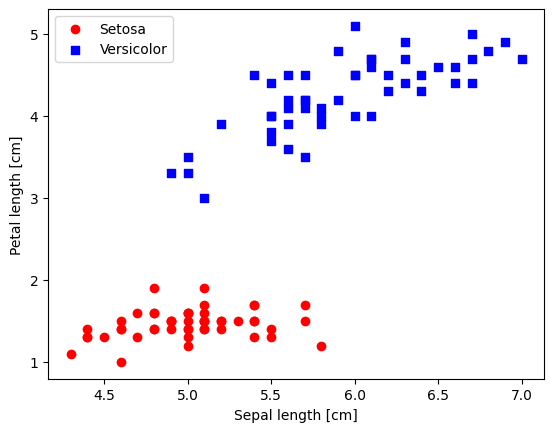

In [9]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],color='blue', marker='s', label='Versicolor')
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

The figure shows the distribution of flower examples in the Iris dataset along the two feature axes: petal length and sepal length (measured in centimeters). In this two-dimensional feature subspace, we can see that a linear decision boundary should be sufficient to separate setosa from versicolor flowers. Thus a linear classifier such as the perceptron should be able to classify the flowers in this dataset perfectly.

Now, it is time to train our adaline algorithm on the Iris data subset that we just extracted. Also, we will plot the misclassification error for each epoch to check whether the algorithm converged and found a decision boundary that separated the two Iris flower classes.

It often requires some experimentation to find a good learning rate $\eta$ for optimal convergence. Let's therefore choose two different learning rates $\eta=0.1$ and $\eta=0.0001$ to start with and plot the loss function versus the nuber of epochs.

As we can see in the resulting loss function plots above, we encountered two different types of problems. The left chart shows what could happen if we choose a learning rate that is too large. Instead of minimizing the loss funcion, the MSE becomes larger in every epoch, because we overshoot the global minimum. On the other hand, we can see that the loss decreases on the right plot, but the chosen learning rate is so small that the algorithm would require a very large number of epochs to converge to the global loss minimum.

Gradient descent is one of the many algorithms that benefit from feature scaling. For example, the standardization is a normalization procedure that helps gradient descent learning to converge more quickly.

Standardization hifts the mean of each feature so that it is centered at zero and each feature has a standard deviation of 1 (unit variance). For instance, to standardize the $jth$ feature, we can simply subtract the sample mean $\mu_j$ from every training example and divide it by its standard deviation $\sigma_j$: $x^{'}_j = \frac{x_j - \mu_j}{\sigma_j}$. Here $x_j$ is a vector consisting of the $jth$ feature values of all training examples $n$ and this standardization technique is applied to each feature $j$ in out dataset.





One of the reasons why standardization helps with gradient descent learning is that it is easier to find a learning rate that works well for all weights (and the bias). If the features are on vastly different scales, a learning rate that works well for updating one weight might be too large or too small to update the other weight equally well. Overall, using standardized features can stabilize the training such that the optimizer has to go through fewer steps to find a good or optimal solution (the global loss minimum).

Standardization can easily be achieved by using the built-in NumPy methods mean and std:

In [10]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

After standardization, we train Adaline again with a learning rate $\eta=0.5$.

In [11]:
adalinesgd = AdalineSGD(eta=0.01, epochs=15)

In [12]:
adalinesgd.fit(X_std, y)

xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.int64'>
xi <class 'numpy.ndarray'>
target <class 'numpy.

In [13]:
from matplotlib.colors import ListedColormap

In [14]:
def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black'
        )

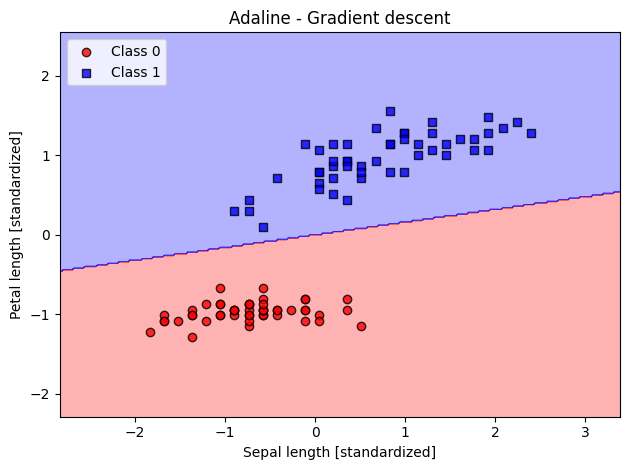

In [15]:
plot_decision_regions(X_std, y, classifier=adalinesgd)
plt.title('Adaline - Gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

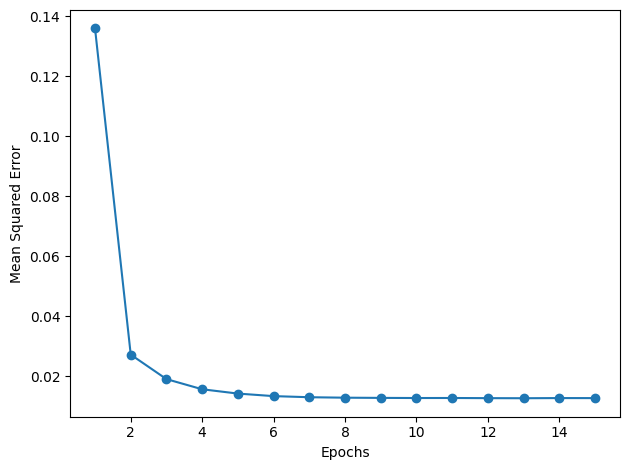

In [16]:
plt.plot(range(1, len(adalinesgd.losses) + 1), adalinesgd.losses, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.tight_layout()
plt.show()

In [17]:
adalinesgd.losses[-1]

np.float64(0.012694630577919282)

As you can see, the average loss goes down pretty quickly, and the final decision boundary after 15 epochs looks similar to the batch gradient descent Adaline.